# Transition Temperatures

`plot_phase_diagram(..., transition_temperatures=True)` labels every invariant of a refined phase diagram with its temperature.
Two kinds of point are tagged in the `locus` column of the `calc_phase_diagram` frame:

* `triple`: three phases coexist on an isotherm,
* `congruent`: two coexisting phases share a composition.

This notebook builds a textbook binary system for every three-phase reaction from `LinePhase`, `IdealSolution` and `FastInterpolatingPhase`, grouped by whether the middle phase decomposes or forms on cooling (eutectic, eutectoid, monotectic, metatectic; peritectic, peritectoid, syntectic), followed by the congruent points. After each diagram the tags are read back from the frame.

## Prelude

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from landau.phases import LinePhase, IdealSolution, FastInterpolatingPhase, kB
from landau.interpolate import PolyFit
from landau.calculate import calc_phase_diagram
from landau.plot import plot_phase_diagram, plot_mu_phase_diagram

Energies are in eV/atom, entropies in units of $k_B$.
A line phase has $f(T) = E - T S$, so a pure component melts at $T_m = \Delta E / \Delta S$.

In [2]:
def line(name, c, E, S):
    return LinePhase(name, fixed_concentration=c, line_energy=E, line_entropy=S * kB)

def ideal(name, E_A, S_A, E_B, S_B):
    """Ideal solution between the terminals A (c=0) and B (c=1)."""
    return IdealSolution(name, line(name + "A", 0, E_A, S_A), line(name + "B", 1, E_B, S_B))

def regular(name, E_A, S_A, E_B, S_B, L0, L1=0):
    """Sub-regular solution with mixing enthalpy c (1 - c) (L0 + L1 (2c - 1)); L0 < 0 attracts, L0 > 0 repels."""
    E_mix = lambda c: c * (1 - c) * (L0 + L1 * (2 * c - 1))
    controls = [
        line(f"{name}{i}", c, (1 - c) * E_A + c * E_B + E_mix(c), (1 - c) * S_A + c * S_B)
        for i, c in enumerate([0, 0.25, 0.5, 0.75, 1])
    ]
    return FastInterpolatingPhase(name, phases=controls, add_entropy=True, interpolator=PolyFit(4))

alpha = line("α", 0, -3.0, 1.0)
beta = line("β", 1, -2.5, 1.0)
liquid = ideal("liquid", -2.8, 3.0, -2.35, 3.0)
Ts = np.linspace(300, 1500, 60)

def diagram(phases, Ts=Ts, ax=None, **kwargs):
    df = calc_phase_diagram(phases, Ts, mu=100)
    plot_phase_diagram(df, transition_temperatures=True, ax=ax, **kwargs)
    return df

def triples(df):
    """The three-phase invariants of a refined frame, one row per coexisting phase."""
    return df.query("locus == 'triple'").sort_values(["T", "c"])[["T", "c", "phase", "refined"]]


## Decomposing reactions

One phase splits into two on cooling: the phase whose composition lies between the other two on the isotherm is stable *above* it.
Eutectic, eutectoid, monotectic and metatectic share this geometry and differ only in which of the three phases are liquid.

### Eutectic

$L \rightarrow \alpha + \beta$.
Two line phases with no mutual solubility and an ideal liquid.
The three-phase isotherm is drawn as a line, its temperature labelled in the two-phase field above it.
In the $\mu$-$T$ diagram the three phases meet in a point.

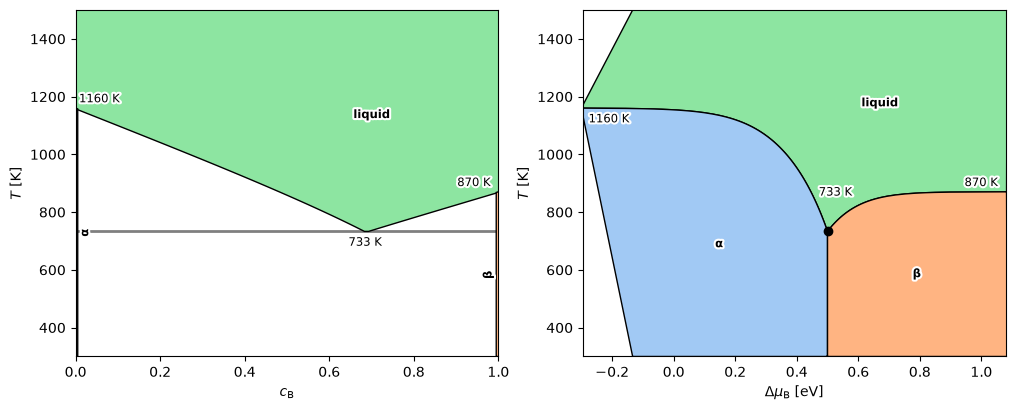

In [3]:
fig, (ax_c, ax_mu) = plt.subplots(1, 2, figsize=(12, 4.5))
df = diagram([alpha, beta, liquid], ax=ax_c, element="B")
plot_mu_phase_diagram(df, element="B", transition_temperatures=True, ax=ax_mu)

In [4]:
triples(df)

,T,c,phase,refined
18120,733.282818,0.000000,α,delaunay-triple
18122,733.282818,0.688104,liquid,delaunay-triple
18121,733.282818,1.000000,β,delaunay-triple


### Eutectoid

$\gamma \rightarrow \alpha + \beta$.
The eutectic geometry with the liquid replaced by a solid solution $\gamma$; the liquid on top melts $\gamma$ through an isomorphous lens.
The allotropic transitions of the pure components, $\alpha \leftrightarrow \gamma$ and $\beta \leftrightarrow \gamma$, are congruent points too.

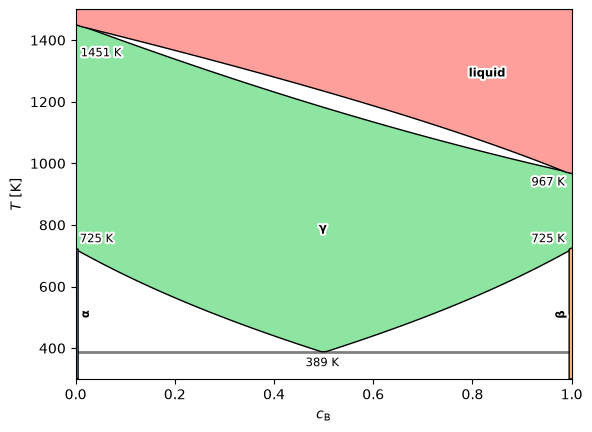

In [5]:
gamma = ideal("γ", -2.95, 1.8, -2.45, 1.8)
df = diagram([alpha, beta, gamma, liquid], element="B")

In [6]:
triples(df)

,T,c,phase,refined
24122,388.592555,0.0,α,delaunay-triple
24121,388.592555,0.5,γ,delaunay-triple
24120,388.592555,1.0,β,delaunay-triple


### Monotectic

$L_1 \rightarrow \alpha + L_2$.
A repulsive liquid separates into two liquids below its critical point, and the miscibility gap runs into the $\alpha$ liquidus.
B has no solid phase in this toy, as in the metatectic below, so the B-rich liquid $L_2$ runs to the bottom of the window instead of ending in a eutectic.
One phase takes part twice here, so the invariant is found by the miscibility-gap tracer rather than from a three-phase simplex; the two liquid rows carry the two branch compositions.

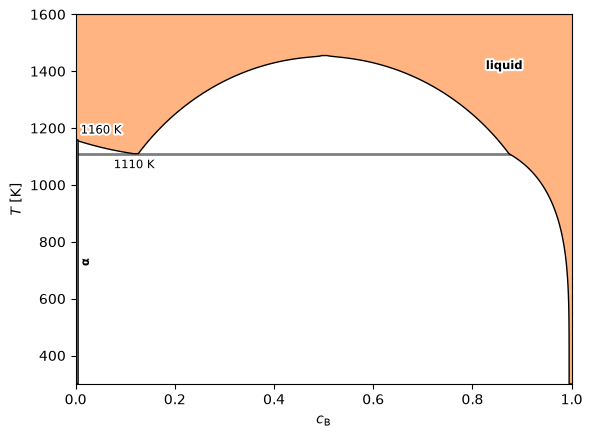

In [7]:
liquid_repulsive = regular("liquid", -2.8, 3.0, -2.35, 3.0, L0=0.25)
df = diagram([alpha, liquid_repulsive], Ts=np.linspace(300, 1600, 80), element="B")

In [8]:
triples(df)

,T,c,phase,refined
17010,1109.972834,0.000000,α,miscibility-gap
17008,1109.972834,0.121364,liquid,miscibility-gap
17009,1109.972834,0.878657,liquid,miscibility-gap


### Metatectic

$\beta \rightarrow \alpha + L$.
Topologically this is the eutectic: the middle phase is stable above the isotherm and splits into the two outer ones on cooling.
What makes it a metatectic is that one of the products is the liquid, so $\beta$ partly melts on cooling.
Here $\beta$ is a high-entropy solid solution on the A side that is only stable at high temperature ($\alpha \leftrightarrow \beta$ at 774 K in pure A), and B has no solid phase in this toy, so the liquid reaches the bottom of the window on the B side; where the $\beta$ field closes it decomposes into $\alpha$ and a B-rich liquid.

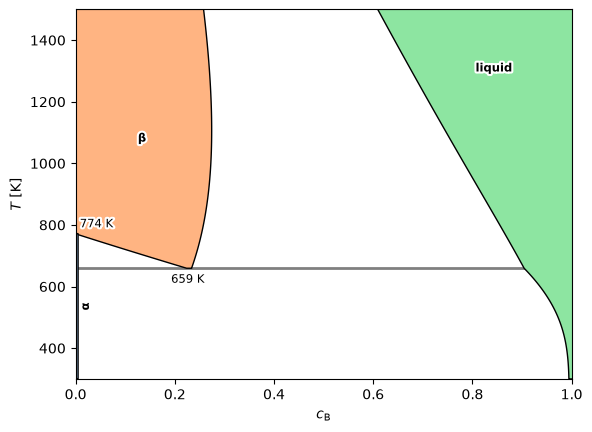

In [9]:
beta_hot = ideal("β", -2.9, 2.5, -2.3, 2.5)
liquid_hot = ideal("liquid", -2.75, 3.0, -2.35, 3.0)
df = diagram([alpha, beta_hot, liquid_hot], element="B")

In [10]:
triples(df)

,T,c,phase,refined
18120,659.434667,0.000000,α,delaunay-triple
18122,659.434667,0.228769,β,delaunay-triple
18121,659.434667,0.909229,liquid,delaunay-triple


## Forming reactions

Two phases combine into one on cooling: the middle phase is stable *below* the isotherm.
Peritectic, peritectoid and syntectic.

### Peritectic

$L + \alpha \rightarrow \beta$.
Two terminal solid solutions, A melting much higher than B.
Both solid-liquid lenses descend towards B, so the liquidus is monotone and the $\beta$ field is capped by the peritectic isotherm above the melting point of B, where $\beta$ forms from $\alpha$ and a liquid richer in B than itself.
Solubilities are exaggerated.

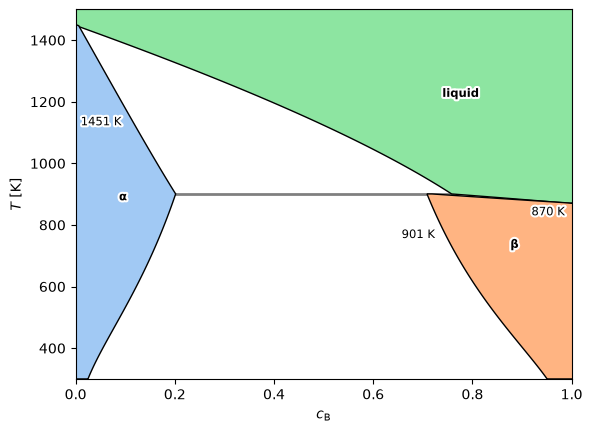

In [11]:
liquid_hot = ideal("liquid", -2.75, 3.0, -2.35, 3.0)
alpha_ss = ideal("α", -3.0, 1.0, -2.40, 1.0)
beta_ss = ideal("β", -2.92, 1.0, -2.5, 1.0)
df = diagram([alpha_ss, beta_ss, liquid_hot], element="B")

In [12]:
triples(df)

,T,c,phase,refined
18120,900.652135,0.196690,α,delaunay-triple
18121,900.652135,0.713432,β,delaunay-triple
18122,900.652135,0.763110,liquid,delaunay-triple


### Peritectoid

$\alpha + \beta \rightarrow \gamma$.
A low-entropy compound that is only stable at low temperature; on heating it decomposes into the two solids, well below the eutectic.

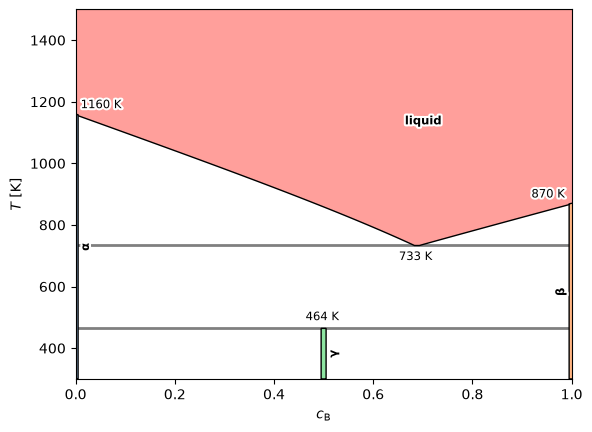

In [13]:
gamma = line("γ", 0.5, -2.77, 0.5)
df = diagram([alpha, beta, gamma, liquid], element="B")

In [14]:
df.query("locus in ['triple', 'congruent']").groupby(["T", "locus"]).phase.agg(list)

T            locus    
464.180753   triple            [β, α, γ]
733.282806   triple       [β, liquid, α]
870.338859   congruent       [β, liquid]
1160.451812  congruent       [α, liquid]
Name: phase, dtype: object

### Syntectic

$L_1 + L_2 \rightarrow \gamma$.
The repulsive liquid of the monotectic section with a compound $\gamma$ at $c = 0.5$ placed under its miscibility gap: where the gap meets the melting point of $\gamma$ the two liquids react to form it, and below that $\gamma$ makes a eutectic with each terminal phase.
As at the monotectic, one phase takes part twice, so the invariant is found by the miscibility-gap tracer and the two liquid rows carry the branch compositions.

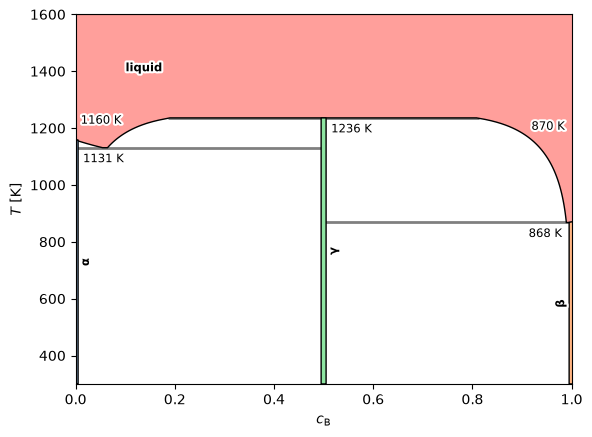

In [15]:
gamma = line("γ", 0.5, -2.78, 1.2)
df = diagram([alpha, beta, gamma, liquid_repulsive], Ts=np.linspace(300, 1600, 80), element="B")

In [16]:
triples(df)

,T,c,phase,refined
32160,867.938605,0.500000,γ,delaunay-triple
32162,867.938605,0.994380,liquid,delaunay-triple
32161,867.938605,1.000000,β,delaunay-triple
32164,1130.968602,0.000000,α,delaunay-triple
32163,1130.968602,0.059337,liquid,delaunay-triple
32165,1130.968602,0.500000,γ,delaunay-triple
33328,1235.806461,0.186822,liquid,miscibility-gap
33330,1235.806461,0.500000,γ,miscibility-gap
33329,1235.806461,0.813376,liquid,miscibility-gap


## Congruent points

Two-phase invariants: the coexisting phases share a composition, so the transformation happens at a point rather than along an isotherm, and the point is tagged `congruent` rather than `triple`.

### Congruently melting compound

A more stable $\gamma$ melts directly into a liquid of its own composition; a congruent maximum in the liquidus, with a eutectic on either side.

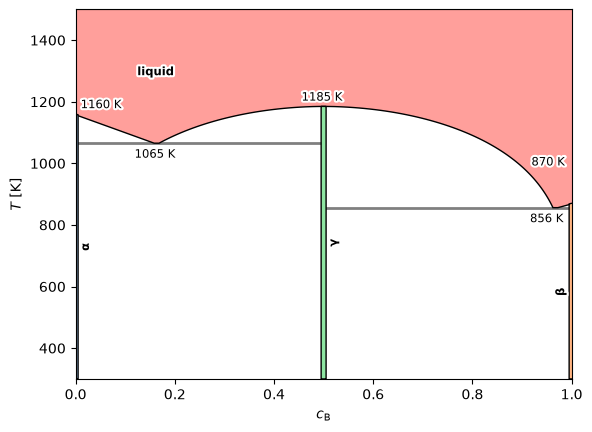

In [17]:
gamma = line("γ", 0.5, -2.85, 1.0)
df = diagram([alpha, beta, gamma, liquid], element="B")

In [18]:
df.query("locus in ['triple', 'congruent']").groupby(["T", "locus"]).phase.agg(list)

T            locus    
856.128585   triple       [γ, β, liquid]
870.338859   congruent       [β, liquid]
1065.459303  triple       [γ, liquid, α]
1160.451812  congruent       [α, liquid]
1184.949158  congruent       [liquid, γ]
Name: phase, dtype: object

### Congruent minimum: the ethanol-water azeotrope

A minimum-boiling azeotrope is the vapour-liquid version of a congruent minimum.
Water and ethanol boil at 373.15 K and 351.4 K, the azeotrope at 351.3 K and 89.4 mol% ethanol.
Entropies of vaporisation come from the real enthalpies; the two liquid interaction parameters are solved so that the liquid and vapour free energies touch with a common slope exactly at the azeotrope.
The azeotrope sits only 0.1 K below the boiling point of ethanol, so the lens is nearly flat from 80 mol% on; both are tagged.

In [19]:
T_w, T_e = 373.15, 351.4
S_w, S_e = 40.65e3 / T_w / 8.314, 38.6e3 / T_e / 8.314   # kB units
c_az, T_az = 0.894, 351.3

# vapour - liquid at the azeotrope temperature, without mixing: E_mix must match it in value and slope at c_az
g = lambda c: (1 - c) * S_w * kB * (T_w - T_az) + c * S_e * kB * (T_e - T_az)
c = c_az
M = np.array([[c * (1 - c), c * (1 - c) * (2 * c - 1)],
              [1 - 2 * c, (1 - 2 * c) * (2 * c - 1) + 2 * c * (1 - c)]])
L0, L1 = np.linalg.solve(M, [g(c), g(1) - g(0)])

ethanol_water = regular("liquid", 0, 0, 0, 0, L0, L1)
vapour = ideal("vapour", S_w * kB * T_w, S_w, S_e * kB * T_e, S_e)

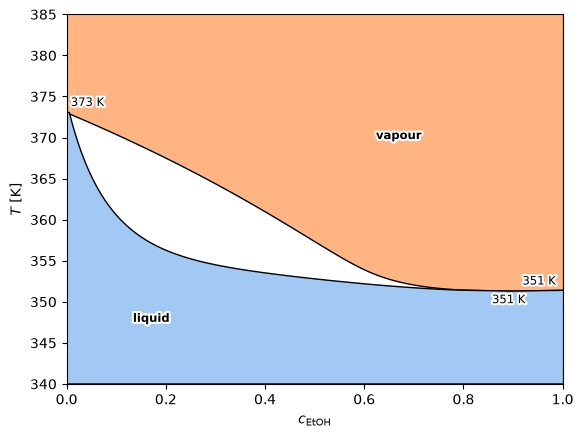

In [20]:
df = diagram([ethanol_water, vapour], Ts=np.linspace(340, 385, 90), element="EtOH")

In [21]:
df.query("locus == 'congruent'")[["T", "c", "phase", "locus"]]

,T,c,phase,locus
18416,351.299991,0.893996,vapour,congruent
18417,351.299991,0.893996,liquid,congruent
18418,373.149990,0.000000,liquid,congruent
18419,373.149990,0.000000,vapour,congruent
18420,351.400005,1.000000,liquid,congruent
18421,351.400005,1.000000,vapour,congruent


## Notes

* The labels only read the `locus` tags back, so an unrefined diagram (`refine=False`) draws none.
* `transition_temperatures=True` also draws the three-phase isotherms; pass `triplepoints=False` to keep only the labels.